# ModelBuilder3.0

**Purpose:** Use the clean quarterly dataset produced by `FeatureBuilder3.0.ipynb` to answer the MBA Finance study research questions.

**Main input:**

`processed/quarterly_features_clean.csv`

**Core study question:**

Can monsoon outcomes and macroeconomic indicators improve quarterly allocation decisions between Indian mid-cap and large-cap equity exposure beyond a simple momentum-based benchmark?

**Outputs are written to:**

`processed/`

This notebook generates RQ-specific tables, charts, model metrics, prediction files, feature-importance outputs, and an Excel workbook for thesis and presentation use.


## Research-question mapping

| RQ | Notebook output |
|---|---|
| RQ1: Do macroeconomic and monsoon indicators improve prediction compared with momentum? | `rq1_metrics.csv`, `rq1_oof_predictions.csv`, `rq1_holdout_predictions.csv` |
| RQ2: Do favorable monsoon conditions precede stronger mid-cap relative performance? | `rq2_good_vs_poor_rain.csv` |
| RQ3: Is rainfall related to economic growth in a stable forecasting sense? | `rq3_rainfall_gdp_relationship.csv`, `rq3_gdp_predictions.csv` |
| RQ4: Which factors matter most for short-term allocation decisions? | `rq4_permutation_importance.csv`, `rq4_directional_allocation_summary.csv` |
| Presentation / appendix support | `results_for_slides.xlsx`, charts in `processed/charts/`, `modelbuilder_manifest.json` |


In [1]:
# =========================
# 0) Imports, folders, configuration
# =========================

import json
import math
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

try:
    import statsmodels.api as sm
    STATSMODELS_AVAILABLE = True
except Exception:
    STATSMODELS_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Project folders. Run this notebook from the project root, e.g. marketpredict/.
PROJECT_ROOT = Path.cwd()
RAW = PROJECT_ROOT / "raw"
PROC = PROJECT_ROOT / "processed"
CHARTS = PROC / "charts"

PROC.mkdir(parents=True, exist_ok=True)
CHARTS.mkdir(parents=True, exist_ok=True)

INPUT_FILE = PROC / "quarterly_features_clean.csv"

RANDOM_STATE = 42
HOLDOUT_QUARTERS = 8   # final 8 quarters held out when enough rows exist
MIN_HOLDOUT_QUARTERS = 4
N_SPLITS_TARGET = 5

print("Project root:", PROJECT_ROOT.resolve())
print("Expected input:", INPUT_FILE.resolve())
print("Processed output folder:", PROC.resolve())
print("Chart output folder:", CHARTS.resolve())


Project root: C:\Users\Local User\Documents\GitHub\marketpredict
Expected input: C:\Users\Local User\Documents\GitHub\marketpredict\processed\quarterly_features_clean.csv
Processed output folder: C:\Users\Local User\Documents\GitHub\marketpredict\processed
Chart output folder: C:\Users\Local User\Documents\GitHub\marketpredict\processed\charts


In [2]:
# =========================
# 1) Helper functions
# =========================

def require_columns(df: pd.DataFrame, required_cols):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(
            "Missing required columns from FeatureBuilder3.0 output: "
            + ", ".join(missing)
            + "\nRe-run FeatureBuilder3.0 and confirm quarterly_features_clean.csv was created."
        )


def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))


def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return float((np.sign(y_true[mask]) == np.sign(y_pred[mask])).mean())


def metric_row(model_name, sample_name, y_true, y_pred, n_features):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return {
            "model": model_name,
            "sample": sample_name,
            "n_obs": 0,
            "n_features": n_features,
            "rmse": np.nan,
            "mae": np.nan,
            "r2": np.nan,
            "directional_accuracy": np.nan,
        }
    yt, yp = y_true[mask], y_pred[mask]
    return {
        "model": model_name,
        "sample": sample_name,
        "n_obs": int(mask.sum()),
        "n_features": int(n_features),
        "rmse": rmse(yt, yp),
        "mae": mean_absolute_error(yt, yp),
        "r2": r2_score(yt, yp) if len(yt) >= 2 else np.nan,
        "directional_accuracy": directional_accuracy(yt, yp),
    }


def make_preprocessor(feature_cols):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), feature_cols)
        ],
        remainder="drop",
    )


def make_pipeline(model, feature_cols):
    return Pipeline([
        ("prep", make_preprocessor(feature_cols)),
        ("model", model),
    ])


def safe_to_csv(df: pd.DataFrame, path: Path, **kwargs):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, **kwargs)
    print("Wrote:", path.resolve())


def save_figure(path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Wrote chart:", path.resolve())
    plt.show()


def choose_time_series_splits(n_train):
    # TimeSeriesSplit needs enough rows. Keep it conservative for quarterly samples.
    if n_train < 12:
        return 2
    return min(N_SPLITS_TARGET, max(2, n_train // 8))


In [3]:
# =========================
# 2) Load FeatureBuilder3.0 output
# =========================

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {INPUT_FILE}. Run FeatureBuilder3.0 first, or update INPUT_FILE to the correct path."
    )

df = pd.read_csv(INPUT_FILE)

# Parse quarter date if present.
if "quarter_end" in df.columns:
    df["quarter_end"] = pd.to_datetime(df["quarter_end"])
    df = df.sort_values("quarter_end").reset_index(drop=True)
else:
    raise ValueError("quarter_end is required in FeatureBuilder3.0 output.")

required = ["quarter_end", "next_q_excess_ret", "lag_excess_ret_1q"]
require_columns(df, required)

# Ensure numeric conversion for all non-label columns where possible.
label_cols = {"quarter_end", "quarter_label"}
for col in df.columns:
    if col not in label_cols:
        df[col] = pd.to_numeric(df[col], errors="ignore")

print("Loaded rows:", len(df))
print("Date range:", df["quarter_end"].min(), "to", df["quarter_end"].max())
print("Columns:")
print(list(df.columns))

display(df.head())


Loaded rows: 40
Date range: 2014-06-30 00:00:00 to 2024-03-31 00:00:00
Columns:
['quarter_end', 'year', 'quarter', 'quarter_label', 'midcap_ret', 'largecap_ret', 'excess_ret', 'cpi_yoy', 'gdp_yoy', 'repo', 'repo_chg_bps', 'rain_anom', 'next_q_excess_ret', 'lag_excess_ret_1q', 'lag_excess_ret_2q', 'lag_cpi_yoy_1q', 'lag_gdp_yoy_1q', 'lag_repo_1q', 'lag_repo_chg_bps_1q', 'lag_rain_anom_1q', 'good_monsoon_flag', 'poor_monsoon_flag', 'normal_monsoon_flag', 'target_direction', 'allocation_signal_label']


,quarter_end,year,quarter,quarter_label,midcap_ret,largecap_ret,excess_ret,cpi_yoy,gdp_yoy,repo,repo_chg_bps,rain_anom,next_q_excess_ret,lag_excess_ret_1q,lag_excess_ret_2q,lag_cpi_yoy_1q,lag_gdp_yoy_1q,lag_repo_1q,lag_repo_chg_bps_1q,lag_rain_anom_1q,good_monsoon_flag,poor_monsoon_flag,normal_monsoon_flag,target_direction,allocation_signal_label
0,2014-06-30,2014,2,2014-Q2,28.847192,13.531070,15.316122,7.859486,7.112080,8.00,0.0,69.879102,-1.747418,0.356270,NaN,8.244298,5.922736,8.0,25.0,69.879102,1,0,0,0,Large-cap outperformed or matched mid-cap next...
1,2014-09-30,2014,3,2014-Q3,2.896304,4.643723,-1.747418,6.681568,7.592544,8.00,0.0,-7.449626,6.216425,15.316122,0.356270,7.859486,7.112080,8.0,0.0,69.879102,0,1,0,1,Mid-cap outperformed large-cap next quarter
2,2014-12-31,2014,4,2014-Q4,10.207737,3.991312,6.216425,4.054538,8.033806,8.00,0.0,-7.449626,0.802069,-1.747418,15.316122,6.681568,7.592544,8.0,0.0,-7.449626,0,1,0,1,Mid-cap outperformed large-cap next quarter
3,2015-03-31,2015,1,2015-Q1,3.316950,2.514880,0.802069,5.272440,7.197433,7.50,-50.0,-7.449626,1.507313,6.216425,-1.747418,4.054538,8.033806,8.0,0.0,-7.449626,0,1,0,1,Mid-cap outperformed large-cap next quarter
4,2015-06-30,2015,2,2015-Q2,0.064609,-1.442704,1.507313,5.090809,9.088683,7.25,-25.0,-7.449626,4.820723,0.802069,6.216425,5.272440,7.197433,7.5,-50.0,-7.449626,0,1,0,1,Mid-cap outperformed large-cap next quarter


In [4]:
# =========================
# 3) Study variables and model feature sets
# =========================

TARGET = "next_q_excess_ret"

# Momentum benchmark: answers whether prior relative return alone helps allocation.
momentum_features = [c for c in ["lag_excess_ret_1q"] if c in df.columns]

# Core enriched variables: aligned with problem statement and objectives.
core_enriched_candidates = [
    "lag_excess_ret_1q",
    "cpi_yoy",
    "gdp_yoy",
    "repo_chg_bps",
    "rain_anom",
]
core_enriched_features = [c for c in core_enriched_candidates if c in df.columns]

# Lagged-only enriched variables: more conservative timing assumption.
lagged_enriched_candidates = [
    "lag_excess_ret_1q",
    "lag_cpi_yoy_1q",
    "lag_gdp_yoy_1q",
    "lag_repo_chg_bps_1q",
    "lag_rain_anom_1q",
]
lagged_enriched_features = [c for c in lagged_enriched_candidates if c in df.columns]

# Full candidate set for feature-importance analysis, while keeping sample size in mind.
rq4_candidates = [
    "lag_excess_ret_1q",
    "lag_excess_ret_2q",
    "cpi_yoy",
    "gdp_yoy",
    "repo",
    "repo_chg_bps",
    "rain_anom",
    "lag_cpi_yoy_1q",
    "lag_gdp_yoy_1q",
    "lag_repo_chg_bps_1q",
    "lag_rain_anom_1q",
    "good_monsoon_flag",
    "poor_monsoon_flag",
    "normal_monsoon_flag",
]
rq4_features = [c for c in rq4_candidates if c in df.columns]

print("Target:", TARGET)
print("Momentum features:", momentum_features)
print("Core enriched features:", core_enriched_features)
print("Lagged enriched features:", lagged_enriched_features)
print("RQ4 candidate features:", rq4_features)

if len(momentum_features) == 0:
    raise ValueError("No momentum feature found. Expected lag_excess_ret_1q.")
if len(core_enriched_features) <= len(momentum_features):
    print("Warning: enriched feature set does not add variables beyond the momentum benchmark.")


Target: next_q_excess_ret
Momentum features: ['lag_excess_ret_1q']
Core enriched features: ['lag_excess_ret_1q', 'cpi_yoy', 'gdp_yoy', 'repo_chg_bps', 'rain_anom']
Lagged enriched features: ['lag_excess_ret_1q', 'lag_cpi_yoy_1q', 'lag_gdp_yoy_1q', 'lag_repo_chg_bps_1q', 'lag_rain_anom_1q']
RQ4 candidate features: ['lag_excess_ret_1q', 'lag_excess_ret_2q', 'cpi_yoy', 'gdp_yoy', 'repo', 'repo_chg_bps', 'rain_anom', 'lag_cpi_yoy_1q', 'lag_gdp_yoy_1q', 'lag_repo_chg_bps_1q', 'lag_rain_anom_1q', 'good_monsoon_flag', 'poor_monsoon_flag', 'normal_monsoon_flag']


In [5]:
# =========================
# 4) Modeling dataset and chronological holdout split
# =========================

model_cols = ["quarter_end", TARGET] + sorted(set(momentum_features + core_enriched_features + lagged_enriched_features + rq4_features))
model_df = df[model_cols].copy()
model_df = model_df.dropna(subset=[TARGET, "lag_excess_ret_1q"]).reset_index(drop=True)

if len(model_df) < 12:
    raise ValueError(
        "Too few clean observations for time-series modeling. Check FeatureBuilder3.0 output and missingness."
    )

holdout_n = HOLDOUT_QUARTERS if len(model_df) >= 28 else MIN_HOLDOUT_QUARTERS
holdout_n = min(holdout_n, max(MIN_HOLDOUT_QUARTERS, len(model_df) // 4))

train_df = model_df.iloc[:-holdout_n].copy()
holdout_df = model_df.iloc[-holdout_n:].copy()

print("Modeling rows:", len(model_df))
print("Training rows:", len(train_df), "|", train_df["quarter_end"].min(), "to", train_df["quarter_end"].max())
print("Holdout rows:", len(holdout_df), "|", holdout_df["quarter_end"].min(), "to", holdout_df["quarter_end"].max())

missing_summary = model_df.isna().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_rate"] = missing_summary["missing_count"] / len(model_df)
safe_to_csv(missing_summary, PROC / "modelbuilder_missingness_summary.csv")

display(model_df.head())


Modeling rows: 40
Training rows: 32 | 2014-06-30 00:00:00 to 2022-03-31 00:00:00
Holdout rows: 8 | 2022-06-30 00:00:00 to 2024-03-31 00:00:00
Wrote: C:\Users\Local User\Documents\GitHub\marketpredict\processed\modelbuilder_missingness_summary.csv


,quarter_end,next_q_excess_ret,cpi_yoy,gdp_yoy,good_monsoon_flag,lag_cpi_yoy_1q,lag_excess_ret_1q,lag_excess_ret_2q,lag_gdp_yoy_1q,lag_rain_anom_1q,lag_repo_chg_bps_1q,normal_monsoon_flag,poor_monsoon_flag,rain_anom,repo,repo_chg_bps
0,2014-06-30,-1.747418,7.859486,7.112080,1,8.244298,0.356270,NaN,5.922736,69.879102,25.0,0,0,69.879102,8.00,0.0
1,2014-09-30,6.216425,6.681568,7.592544,0,7.859486,15.316122,0.356270,7.112080,69.879102,0.0,0,1,-7.449626,8.00,0.0
2,2014-12-31,0.802069,4.054538,8.033806,0,6.681568,-1.747418,15.316122,7.592544,-7.449626,0.0,0,1,-7.449626,8.00,0.0
3,2015-03-31,1.507313,5.272440,7.197433,0,4.054538,6.216425,-1.747418,8.033806,-7.449626,0.0,0,1,-7.449626,7.50,-50.0
4,2015-06-30,4.820723,5.090809,9.088683,0,5.272440,0.802069,6.216425,7.197433,-7.449626,-50.0,0,1,-7.449626,7.25,-25.0


In [6]:
# =========================
# 5) RQ1: Benchmark versus enriched prediction models
# =========================

model_specs = []

model_specs.append({
    "name": "Momentum_Linear",
    "features": momentum_features,
    "estimator": LinearRegression(),
})

if len(core_enriched_features) > len(momentum_features):
    model_specs.extend([
        {
            "name": "Core_Enriched_Ridge",
            "features": core_enriched_features,
            "estimator": Ridge(alpha=1.0),
        },
        {
            "name": "Core_Enriched_RandomForest",
            "features": core_enriched_features,
            "estimator": RandomForestRegressor(
                n_estimators=300,
                max_depth=3,
                min_samples_leaf=3,
                random_state=RANDOM_STATE,
            ),
        },
    ])

if len(lagged_enriched_features) > len(momentum_features):
    model_specs.append({
        "name": "Lagged_Enriched_Ridge",
        "features": lagged_enriched_features,
        "estimator": Ridge(alpha=1.0),
    })

# Keep only specs with available features.
model_specs = [s for s in model_specs if len(s["features"]) > 0]

n_splits = choose_time_series_splits(len(train_df))
ts_cv = TimeSeriesSplit(n_splits=n_splits)

metrics = []
oof_frames = []
holdout_frames = []

for spec in model_specs:
    name = spec["name"]
    features = spec["features"]
    pipe = make_pipeline(spec["estimator"], features)

    X_train = train_df[features]
    y_train = train_df[TARGET]
    X_holdout = holdout_df[features]
    y_holdout = holdout_df[TARGET]

    # Out-of-fold predictions on training set.
    oof_pred = pd.Series(index=train_df.index, dtype=float)
    fold_id = pd.Series(index=train_df.index, dtype=float)

    for fold, (tr_idx, val_idx) in enumerate(ts_cv.split(train_df), start=1):
        fold_model = clone(pipe)
        fold_model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        preds = fold_model.predict(X_train.iloc[val_idx])
        oof_pred.iloc[val_idx] = preds
        fold_id.iloc[val_idx] = fold

    valid_oof = oof_pred.notna()
    metrics.append(metric_row(name, "time_series_cv_oof", y_train[valid_oof], oof_pred[valid_oof], len(features)))

    oof_frame = pd.DataFrame({
        "quarter_end": train_df.loc[valid_oof, "quarter_end"].values,
        "model": name,
        "fold": fold_id[valid_oof].astype(int).values,
        "actual_next_q_excess_ret": y_train[valid_oof].values,
        "pred_next_q_excess_ret": oof_pred[valid_oof].values,
        "actual_direction": (y_train[valid_oof].values > 0).astype(int),
        "pred_direction": (oof_pred[valid_oof].values > 0).astype(int),
    })
    oof_frames.append(oof_frame)

    # Fit final model and evaluate holdout.
    fitted = clone(pipe)
    fitted.fit(X_train, y_train)
    holdout_pred = fitted.predict(X_holdout)
    metrics.append(metric_row(name, "chronological_holdout", y_holdout, holdout_pred, len(features)))

    holdout_frame = pd.DataFrame({
        "quarter_end": holdout_df["quarter_end"].values,
        "model": name,
        "actual_next_q_excess_ret": y_holdout.values,
        "pred_next_q_excess_ret": holdout_pred,
        "actual_direction": (y_holdout.values > 0).astype(int),
        "pred_direction": (holdout_pred > 0).astype(int),
    })
    holdout_frames.append(holdout_frame)

rq1_metrics = pd.DataFrame(metrics).sort_values(["sample", "rmse", "mae"]).reset_index(drop=True)
rq1_oof = pd.concat(oof_frames, ignore_index=True) if oof_frames else pd.DataFrame()
rq1_holdout = pd.concat(holdout_frames, ignore_index=True) if holdout_frames else pd.DataFrame()

safe_to_csv(rq1_metrics, PROC / "rq1_metrics.csv", float_format="%.6f")
safe_to_csv(rq1_oof, PROC / "rq1_oof_predictions.csv", float_format="%.6f")
safe_to_csv(rq1_holdout, PROC / "rq1_holdout_predictions.csv", float_format="%.6f")

display(rq1_metrics)


Wrote: C:\Users\Local User\Documents\GitHub\marketpredict\processed\rq1_metrics.csv
Wrote: C:\Users\Local User\Documents\GitHub\marketpredict\processed\rq1_oof_predictions.csv
Wrote: C:\Users\Local User\Documents\GitHub\marketpredict\processed\rq1_holdout_predictions.csv


,model,sample,n_obs,n_features,rmse,mae,r2,directional_accuracy
0,Lagged_Enriched_Ridge,chronological_holdout,8,5,6.045613,5.059937,-0.629912,0.750000
1,Momentum_Linear,chronological_holdout,8,1,6.276745,5.234560,-0.756921,0.750000
2,Core_Enriched_RandomForest,chronological_holdout,8,5,6.632440,5.676120,-0.961688,0.500000
3,Core_Enriched_Ridge,chronological_holdout,8,5,7.586651,5.935238,-1.566750,0.500000
4,Momentum_Linear,time_series_cv_oof,24,1,5.928516,5.019931,-0.162068,0.458333
5,Core_Enriched_RandomForest,time_series_cv_oof,24,5,6.165725,5.242536,-0.256921,0.416667
6,Core_Enriched_Ridge,time_series_cv_oof,24,5,8.702012,6.695499,-1.503680,0.541667
7,Lagged_Enriched_Ridge,time_series_cv_oof,24,5,13.779541,8.545466,-5.277822,0.541667


Wrote chart: C:\Users\Local User\Documents\GitHub\marketpredict\processed\charts\rq1_holdout_actual_vs_predicted.png


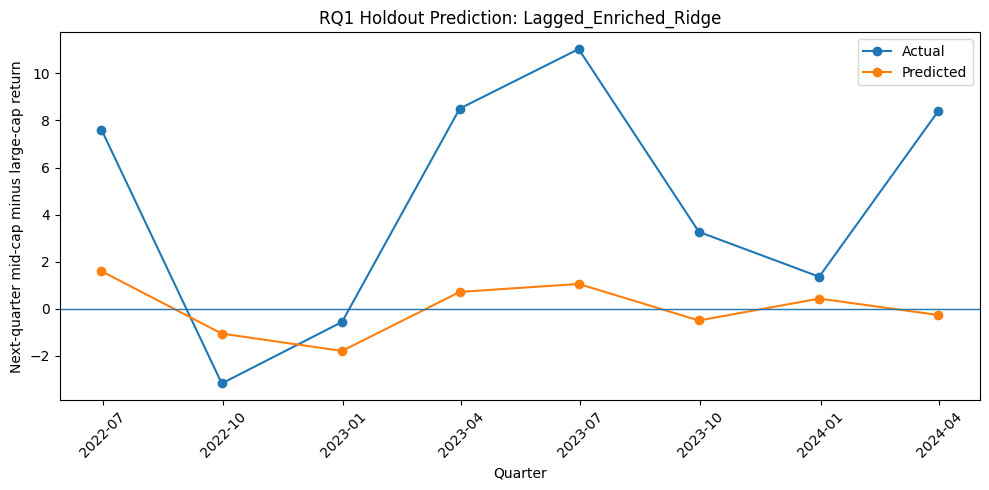

In [7]:
# =========================
# 6) RQ1 chart: actual versus predicted holdout values
# =========================

if not rq1_holdout.empty:
    best_holdout_model = (
        rq1_metrics[rq1_metrics["sample"] == "chronological_holdout"]
        .sort_values(["rmse", "mae"])
        .iloc[0]["model"]
    )
    plot_df = rq1_holdout[rq1_holdout["model"] == best_holdout_model].copy()

    plt.figure(figsize=(10, 5))
    plt.plot(plot_df["quarter_end"], plot_df["actual_next_q_excess_ret"], marker="o", label="Actual")
    plt.plot(plot_df["quarter_end"], plot_df["pred_next_q_excess_ret"], marker="o", label="Predicted")
    plt.axhline(0, linewidth=1)
    plt.title(f"RQ1 Holdout Prediction: {best_holdout_model}")
    plt.xlabel("Quarter")
    plt.ylabel("Next-quarter mid-cap minus large-cap return")
    plt.xticks(rotation=45)
    plt.legend()
    save_figure(CHARTS / "rq1_holdout_actual_vs_predicted.png")
else:
    best_holdout_model = None
    print("No RQ1 holdout predictions available for charting.")


In [8]:
# =========================
# 7) RQ2: Good versus poor monsoon periods
# =========================

rq2_rows = []
comparison_result = {}

if "rain_anom" in df.columns:
    rq2_df = df.dropna(subset=["rain_anom", TARGET]).copy()

    # Use FeatureBuilder flags when present; otherwise classify directly.
    if "good_monsoon_flag" not in rq2_df.columns:
        rq2_df["good_monsoon_flag"] = (rq2_df["rain_anom"] >= 5).astype(int)
    if "poor_monsoon_flag" not in rq2_df.columns:
        rq2_df["poor_monsoon_flag"] = (rq2_df["rain_anom"] <= -5).astype(int)

    conditions = [
        ("Good monsoon", rq2_df["good_monsoon_flag"] == 1),
        ("Poor monsoon", rq2_df["poor_monsoon_flag"] == 1),
        ("Normal monsoon", (rq2_df["good_monsoon_flag"] != 1) & (rq2_df["poor_monsoon_flag"] != 1)),
    ]

    for label, mask in conditions:
        values = rq2_df.loc[mask, TARGET].dropna()
        rq2_rows.append({
            "monsoon_group": label,
            "n_quarters": int(values.shape[0]),
            "avg_next_q_excess_ret": values.mean() if len(values) else np.nan,
            "median_next_q_excess_ret": values.median() if len(values) else np.nan,
            "std_next_q_excess_ret": values.std(ddof=1) if len(values) > 1 else np.nan,
            "positive_rate": (values > 0).mean() if len(values) else np.nan,
        })

    good_values = rq2_df.loc[rq2_df["good_monsoon_flag"] == 1, TARGET].dropna()
    poor_values = rq2_df.loc[rq2_df["poor_monsoon_flag"] == 1, TARGET].dropna()

    if SCIPY_AVAILABLE and len(good_values) >= 2 and len(poor_values) >= 2:
        t_stat, p_value = stats.ttest_ind(good_values, poor_values, equal_var=False, nan_policy="omit")
        comparison_result = {
            "test": "Welch t-test",
            "group_1": "Good monsoon",
            "group_2": "Poor monsoon",
            "mean_difference_good_minus_poor": good_values.mean() - poor_values.mean(),
            "t_stat": t_stat,
            "p_value": p_value,
        }
    else:
        comparison_result = {
            "test": "Not run",
            "reason": "Need scipy and at least two observations in good and poor monsoon groups.",
            "mean_difference_good_minus_poor": good_values.mean() - poor_values.mean() if len(good_values) and len(poor_values) else np.nan,
        }

    rq2_summary = pd.DataFrame(rq2_rows)
    rq2_test = pd.DataFrame([comparison_result])
    rq2_output = pd.concat([rq2_summary, rq2_test], axis=0, ignore_index=True)
else:
    rq2_output = pd.DataFrame([{"status": "rain_anom not available; RQ2 could not be tested."}])

safe_to_csv(rq2_output, PROC / "rq2_good_vs_poor_rain.csv", float_format="%.6f")
display(rq2_output)


Wrote: C:\Users\Local User\Documents\GitHub\marketpredict\processed\rq2_good_vs_poor_rain.csv


,monsoon_group,n_quarters,avg_next_q_excess_ret,median_next_q_excess_ret,std_next_q_excess_ret,positive_rate,test,group_1,group_2,mean_difference_good_minus_poor,t_stat,p_value
0,Good monsoon,13.0,2.533529,-0.560000,5.102510,0.461538,NaN,NaN,NaN,NaN,NaN,NaN
1,Poor monsoon,19.0,1.870280,1.507313,4.396818,0.736842,NaN,NaN,NaN,NaN,NaN,NaN
2,Normal monsoon,8.0,-1.237367,-2.184376,6.928466,0.375000,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,Welch t-test,Good monsoon,Poor monsoon,0.663249,0.381643,0.706187


Wrote chart: C:\Users\Local User\Documents\GitHub\marketpredict\processed\charts\rq2_return_by_monsoon_group.png


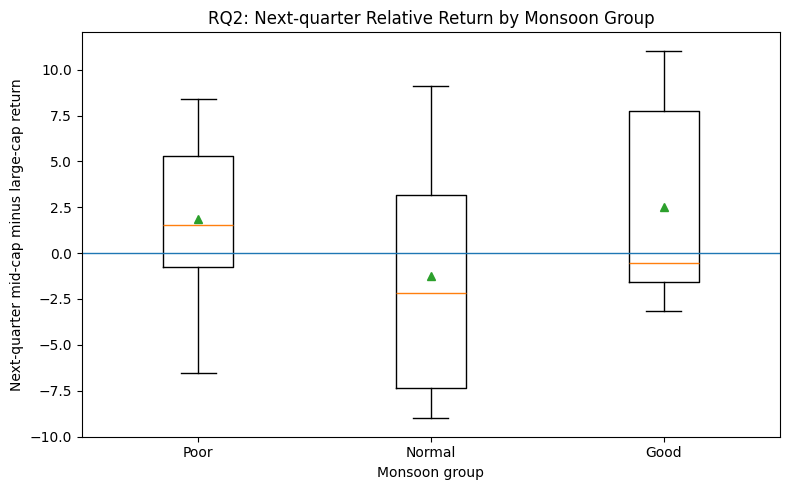

In [9]:
# =========================
# 8) RQ2 chart: next-quarter relative return by monsoon group
# =========================

if "rain_anom" in df.columns:
    plot_df = df.dropna(subset=["rain_anom", TARGET]).copy()
    if "good_monsoon_flag" not in plot_df.columns:
        plot_df["good_monsoon_flag"] = (plot_df["rain_anom"] >= 5).astype(int)
    if "poor_monsoon_flag" not in plot_df.columns:
        plot_df["poor_monsoon_flag"] = (plot_df["rain_anom"] <= -5).astype(int)

    def monsoon_group(row):
        if row.get("good_monsoon_flag", 0) == 1:
            return "Good"
        if row.get("poor_monsoon_flag", 0) == 1:
            return "Poor"
        return "Normal"

    plot_df["monsoon_group"] = plot_df.apply(monsoon_group, axis=1)
    order = [g for g in ["Poor", "Normal", "Good"] if g in plot_df["monsoon_group"].unique()]

    data_to_plot = [plot_df.loc[plot_df["monsoon_group"] == g, TARGET].values for g in order]

    plt.figure(figsize=(8, 5))
    plt.boxplot(data_to_plot, labels=order, showmeans=True)
    plt.axhline(0, linewidth=1)
    plt.title("RQ2: Next-quarter Relative Return by Monsoon Group")
    plt.xlabel("Monsoon group")
    plt.ylabel("Next-quarter mid-cap minus large-cap return")
    save_figure(CHARTS / "rq2_return_by_monsoon_group.png")
else:
    print("rain_anom not available; skipping RQ2 chart.")


In [10]:
# =========================
# 9) RQ3: Rainfall and GDP growth relationship
# =========================

rq3_records = []
rq3_predictions = pd.DataFrame()

if {"rain_anom", "gdp_yoy"}.issubset(df.columns):
    rq3_df = df.dropna(subset=["rain_anom", "gdp_yoy"]).copy().reset_index(drop=True)

    candidate_predictors = ["rain_anom"]
    if "lag_rain_anom_1q" in rq3_df.columns:
        candidate_predictors.append("lag_rain_anom_1q")

    for predictor in candidate_predictors:
        sub = rq3_df.dropna(subset=[predictor, "gdp_yoy"]).copy()
        if len(sub) >= 8:
            corr = sub[predictor].corr(sub["gdp_yoy"])
            record = {
                "model": f"gdp_yoy_on_{predictor}",
                "predictor": predictor,
                "n_obs": len(sub),
                "correlation": corr,
            }

            if STATSMODELS_AVAILABLE:
                X = sm.add_constant(sub[[predictor]])
                y = sub["gdp_yoy"]
                ols = sm.OLS(y, X).fit()
                record.update({
                    "intercept": ols.params.get("const", np.nan),
                    "slope": ols.params.get(predictor, np.nan),
                    "r2": ols.rsquared,
                    "p_value_slope": ols.pvalues.get(predictor, np.nan),
                    "aic": ols.aic,
                })
                preds = sub[["quarter_end", "gdp_yoy", predictor]].copy()
                preds["model"] = record["model"]
                preds["pred_gdp_yoy"] = ols.predict(X)
                rq3_predictions = pd.concat([rq3_predictions, preds], ignore_index=True)
            else:
                lr = LinearRegression()
                X = sub[[predictor]]
                y = sub["gdp_yoy"]
                lr.fit(X, y)
                pred = lr.predict(X)
                record.update({
                    "intercept": float(lr.intercept_),
                    "slope": float(lr.coef_[0]),
                    "r2": r2_score(y, pred),
                    "p_value_slope": np.nan,
                    "aic": np.nan,
                })
                preds = sub[["quarter_end", "gdp_yoy", predictor]].copy()
                preds["model"] = record["model"]
                preds["pred_gdp_yoy"] = pred
                rq3_predictions = pd.concat([rq3_predictions, preds], ignore_index=True)

            rq3_records.append(record)
        else:
            rq3_records.append({
                "model": f"gdp_yoy_on_{predictor}",
                "predictor": predictor,
                "n_obs": len(sub),
                "status": "Not enough observations for reliable estimation.",
            })

    rq3_relationship = pd.DataFrame(rq3_records)
else:
    rq3_relationship = pd.DataFrame([{"status": "rain_anom and/or gdp_yoy not available; RQ3 could not be tested."}])

safe_to_csv(rq3_relationship, PROC / "rq3_rainfall_gdp_relationship.csv", float_format="%.6f")
safe_to_csv(rq3_predictions, PROC / "rq3_gdp_predictions.csv", float_format="%.6f")

display(rq3_relationship)


Wrote: C:\Users\Local User\Documents\GitHub\marketpredict\processed\rq3_rainfall_gdp_relationship.csv
Wrote: C:\Users\Local User\Documents\GitHub\marketpredict\processed\rq3_gdp_predictions.csv


,model,predictor,n_obs,correlation,intercept,slope,r2,p_value_slope,aic
0,gdp_yoy_on_rain_anom,rain_anom,40,0.164293,5.891798,0.047826,0.026992,0.311042,261.066018
1,gdp_yoy_on_lag_rain_anom_1q,lag_rain_anom_1q,40,0.132188,5.895432,0.034812,0.017474,0.416163,261.455424


Wrote chart: C:\Users\Local User\Documents\GitHub\marketpredict\processed\charts\rq3_rainfall_vs_gdp.png


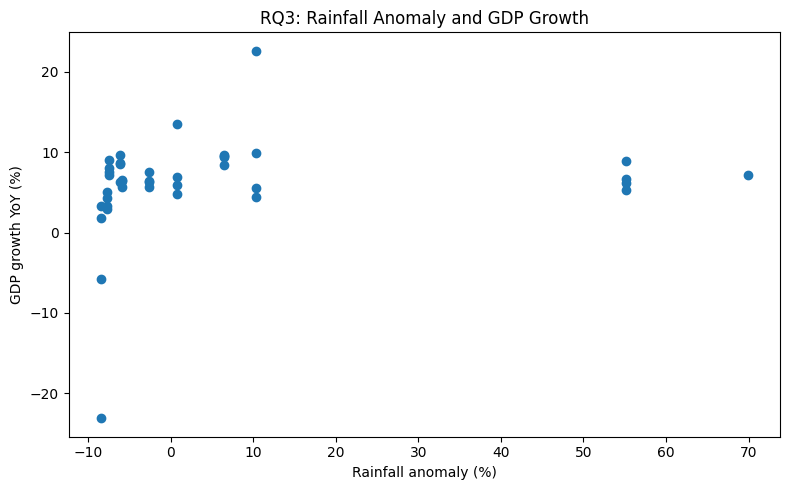

In [11]:
# =========================
# 10) RQ3 chart: rainfall anomaly versus GDP growth
# =========================

if {"rain_anom", "gdp_yoy"}.issubset(df.columns):
    plot_df = df.dropna(subset=["rain_anom", "gdp_yoy"]).copy()
    if len(plot_df) >= 4:
        plt.figure(figsize=(8, 5))
        plt.scatter(plot_df["rain_anom"], plot_df["gdp_yoy"])
        plt.title("RQ3: Rainfall Anomaly and GDP Growth")
        plt.xlabel("Rainfall anomaly (%)")
        plt.ylabel("GDP growth YoY (%)")
        save_figure(CHARTS / "rq3_rainfall_vs_gdp.png")
    else:
        print("Not enough observations for RQ3 chart.")
else:
    print("rain_anom and/or gdp_yoy not available; skipping RQ3 chart.")


In [12]:
# =========================
# 11) RQ4: Feature relevance for allocation decisions
# =========================

# Choose a practical model for feature importance.
# Gradient boosting is used only when enough rows and enough features exist; otherwise Ridge is used.
importance_features = rq4_features.copy()
importance_features = [f for f in importance_features if f in model_df.columns]

if len(importance_features) >= 2 and len(train_df) >= 16 and len(holdout_df) >= 4:
    if len(train_df) >= 24:
        importance_estimator = GradientBoostingRegressor(
            random_state=RANDOM_STATE,
            n_estimators=120,
            learning_rate=0.05,
            max_depth=2,
        )
        importance_model_name = "GradientBoostingRegressor"
    else:
        importance_estimator = Ridge(alpha=1.0)
        importance_model_name = "Ridge"

    importance_pipe = make_pipeline(importance_estimator, importance_features)
    importance_pipe.fit(train_df[importance_features], train_df[TARGET])

    base_holdout_pred = importance_pipe.predict(holdout_df[importance_features])
    base_rmse = rmse(holdout_df[TARGET], base_holdout_pred)
    base_da = directional_accuracy(holdout_df[TARGET], base_holdout_pred)

    try:
        perm = permutation_importance(
            importance_pipe,
            holdout_df[importance_features],
            holdout_df[TARGET],
            n_repeats=100,
            random_state=RANDOM_STATE,
            scoring="neg_root_mean_squared_error",
        )
        rq4_importance = pd.DataFrame({
            "feature": importance_features,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
            "model": importance_model_name,
            "sample": "chronological_holdout",
            "base_holdout_rmse": base_rmse,
            "base_holdout_directional_accuracy": base_da,
        }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
    except Exception as ex:
        rq4_importance = pd.DataFrame([{
            "status": "Permutation importance failed.",
            "error": str(ex),
            "model": importance_model_name,
        }])
else:
    rq4_importance = pd.DataFrame([{
        "status": "Not enough features or observations for RQ4 permutation importance.",
        "n_features": len(importance_features),
        "n_train": len(train_df),
        "n_holdout": len(holdout_df),
    }])

safe_to_csv(rq4_importance, PROC / "rq4_permutation_importance.csv", float_format="%.6f")
display(rq4_importance)


Wrote: C:\Users\Local User\Documents\GitHub\marketpredict\processed\rq4_permutation_importance.csv


,feature,importance_mean,importance_std,model,sample,base_holdout_rmse,base_holdout_directional_accuracy
0,lag_rain_anom_1q,1.075272,0.696054,GradientBoostingRegressor,chronological_holdout,5.121331,0.625
1,lag_gdp_yoy_1q,0.292753,0.357151,GradientBoostingRegressor,chronological_holdout,5.121331,0.625
2,lag_excess_ret_1q,0.281354,0.185004,GradientBoostingRegressor,chronological_holdout,5.121331,0.625
3,lag_cpi_yoy_1q,0.272848,0.462473,GradientBoostingRegressor,chronological_holdout,5.121331,0.625
4,rain_anom,0.156427,0.215085,GradientBoostingRegressor,chronological_holdout,5.121331,0.625
5,repo,0.019070,0.018322,GradientBoostingRegressor,chronological_holdout,5.121331,0.625
6,lag_repo_chg_bps_1q,0.018388,0.033367,GradientBoostingRegressor,chronological_holdout,5.121331,0.625
7,poor_monsoon_flag,0.017490,0.041186,GradientBoostingRegressor,chronological_holdout,5.121331,0.625
8,lag_excess_ret_2q,0.003527,0.007770,GradientBoostingRegressor,chronological_holdout,5.121331,0.625
9,repo_chg_bps,0.000000,0.000000,GradientBoostingRegressor,chronological_holdout,5.121331,0.625


Wrote chart: C:\Users\Local User\Documents\GitHub\marketpredict\processed\charts\rq4_permutation_importance.png


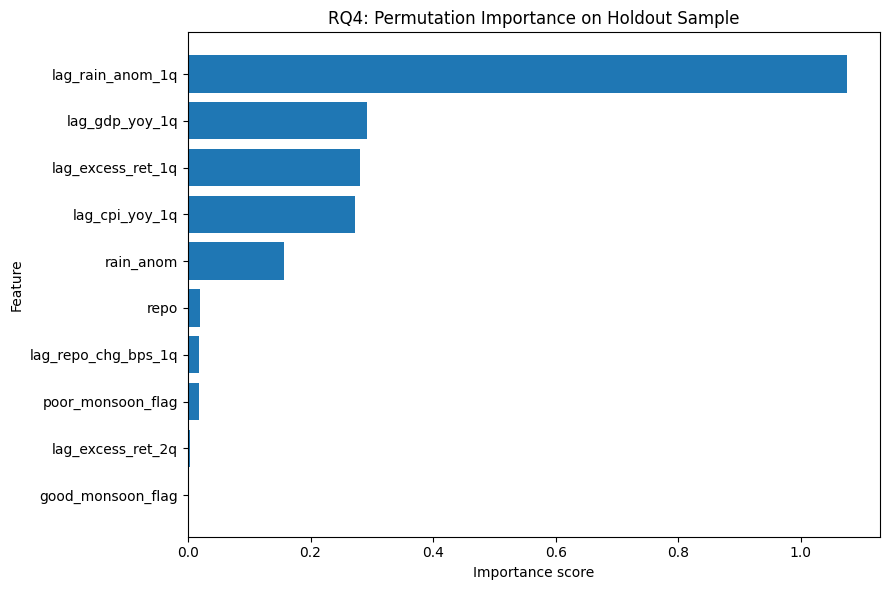

In [13]:
# =========================
# 12) RQ4 chart: feature importance
# =========================

if "importance_mean" in rq4_importance.columns and rq4_importance["importance_mean"].notna().any():
    plot_df = rq4_importance.sort_values("importance_mean", ascending=True).tail(10)

    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["feature"], plot_df["importance_mean"])
    plt.title("RQ4: Permutation Importance on Holdout Sample")
    plt.xlabel("Importance score")
    plt.ylabel("Feature")
    save_figure(CHARTS / "rq4_permutation_importance.png")
else:
    print("No valid RQ4 importance values available for charting.")


In [14]:
# =========================
# 13) Directional allocation summary
# =========================

# Convert predictions into a simple allocation signal:
# predicted next_q_excess_ret > 0 => mid-cap tilt; otherwise large-cap tilt.

allocation_frames = []
if not rq1_holdout.empty:
    for model_name, g in rq1_holdout.groupby("model"):
        g = g.copy()
        g["allocation_signal"] = np.where(g["pred_next_q_excess_ret"] > 0, "Mid-cap tilt", "Large-cap tilt")
        g["realized_winner"] = np.where(g["actual_next_q_excess_ret"] > 0, "Mid-cap", "Large-cap")
        g["correct_tilt"] = (g["actual_direction"] == g["pred_direction"]).astype(int)
        allocation_frames.append(g)

if allocation_frames:
    allocation_detail = pd.concat(allocation_frames, ignore_index=True)
    allocation_summary = (
        allocation_detail.groupby("model")
        .agg(
            n_quarters=("quarter_end", "count"),
            correct_tilt_rate=("correct_tilt", "mean"),
            avg_actual_return_when_midcap_signal=("actual_next_q_excess_ret", lambda x: np.nan),
        )
        .reset_index()
    )

    # More interpretable conditional return summaries.
    rows = []
    for model_name, g in allocation_detail.groupby("model"):
        mid_signal = g[g["allocation_signal"] == "Mid-cap tilt"]
        large_signal = g[g["allocation_signal"] == "Large-cap tilt"]
        rows.append({
            "model": model_name,
            "n_holdout_quarters": len(g),
            "correct_tilt_rate": g["correct_tilt"].mean(),
            "n_midcap_signals": len(mid_signal),
            "avg_actual_excess_ret_after_midcap_signal": mid_signal["actual_next_q_excess_ret"].mean() if len(mid_signal) else np.nan,
            "n_largecap_signals": len(large_signal),
            "avg_actual_excess_ret_after_largecap_signal": large_signal["actual_next_q_excess_ret"].mean() if len(large_signal) else np.nan,
        })
    rq4_allocation_summary = pd.DataFrame(rows).sort_values("correct_tilt_rate", ascending=False)
else:
    allocation_detail = pd.DataFrame()
    rq4_allocation_summary = pd.DataFrame([{"status": "No holdout prediction file available."}])

safe_to_csv(allocation_detail, PROC / "rq4_directional_allocation_detail.csv", float_format="%.6f")
safe_to_csv(rq4_allocation_summary, PROC / "rq4_directional_allocation_summary.csv", float_format="%.6f")

display(rq4_allocation_summary)


Wrote: C:\Users\Local User\Documents\GitHub\marketpredict\processed\rq4_directional_allocation_detail.csv
Wrote: C:\Users\Local User\Documents\GitHub\marketpredict\processed\rq4_directional_allocation_summary.csv


,model,n_holdout_quarters,correct_tilt_rate,n_midcap_signals,avg_actual_excess_ret_after_midcap_signal,n_largecap_signals,avg_actual_excess_ret_after_largecap_signal
2,Lagged_Enriched_Ridge,8,0.75,4,7.127315,4,1.982099
3,Momentum_Linear,8,0.75,8,4.554707,0,NaN
0,Core_Enriched_RandomForest,8,0.50,6,2.834638,2,9.714914
1,Core_Enriched_Ridge,8,0.50,2,2.313714,6,5.301704


In [15]:
# =========================
# 14) Create Excel workbook for thesis tables and slides
# =========================

excel_path = PROC / "results_for_slides.xlsx"

sheets = {
    "rq1_metrics": rq1_metrics,
    "rq1_oof_predictions": rq1_oof,
    "rq1_holdout_predictions": rq1_holdout,
    "rq2_good_vs_poor": rq2_output,
    "rq3_rainfall_gdp": rq3_relationship,
    "rq3_gdp_predictions": rq3_predictions,
    "rq4_importance": rq4_importance,
    "rq4_allocation_summary": rq4_allocation_summary,
    "missingness": missing_summary,
}

with pd.ExcelWriter(excel_path) as writer:
    for sheet_name, sheet_df in sheets.items():
        safe_name = sheet_name[:31]
        if sheet_df is None or sheet_df.empty:
            pd.DataFrame([{"status": "No rows generated."}]).to_excel(writer, sheet_name=safe_name, index=False)
        else:
            sheet_df.to_excel(writer, sheet_name=safe_name, index=False)

print("Wrote Excel workbook:", excel_path.resolve())


Wrote Excel workbook: C:\Users\Local User\Documents\GitHub\marketpredict\processed\results_for_slides.xlsx


In [16]:
# =========================
# 15) Short interpretation helper for thesis drafting
# =========================

interpretation_lines = []

# RQ1 interpretation
try:
    holdout_metrics = rq1_metrics[rq1_metrics["sample"] == "chronological_holdout"].sort_values("rmse")
    if not holdout_metrics.empty:
        best = holdout_metrics.iloc[0]
        momentum = holdout_metrics[holdout_metrics["model"] == "Momentum_Linear"]
        interpretation_lines.append(
            f"RQ1: The best holdout model by RMSE was {best['model']} with RMSE={best['rmse']:.4f} "
            f"and directional accuracy={best['directional_accuracy']:.2%}."
        )
        if not momentum.empty:
            mom = momentum.iloc[0]
            interpretation_lines.append(
                f"The momentum benchmark reported RMSE={mom['rmse']:.4f} and directional accuracy={mom['directional_accuracy']:.2%}."
            )
except Exception as ex:
    interpretation_lines.append(f"RQ1 interpretation not generated: {ex}")

# RQ2 interpretation
try:
    if "monsoon_group" in rq2_output.columns:
        good_row = rq2_output[rq2_output["monsoon_group"] == "Good monsoon"]
        poor_row = rq2_output[rq2_output["monsoon_group"] == "Poor monsoon"]
        if not good_row.empty and not poor_row.empty:
            interpretation_lines.append(
                f"RQ2: Good monsoon quarters had average next-quarter excess return "
                f"{good_row.iloc[0]['avg_next_q_excess_ret']:.4f}; poor monsoon quarters had "
                f"{poor_row.iloc[0]['avg_next_q_excess_ret']:.4f}."
            )
except Exception as ex:
    interpretation_lines.append(f"RQ2 interpretation not generated: {ex}")

# RQ3 interpretation
try:
    if "r2" in rq3_relationship.columns and rq3_relationship["r2"].notna().any():
        top_rq3 = rq3_relationship.sort_values("r2", ascending=False).iloc[0]
        interpretation_lines.append(
            f"RQ3: The strongest rainfall-GDP specification was {top_rq3['model']} with R²={top_rq3['r2']:.4f}."
        )
except Exception as ex:
    interpretation_lines.append(f"RQ3 interpretation not generated: {ex}")

# RQ4 interpretation
try:
    if "importance_mean" in rq4_importance.columns and rq4_importance["importance_mean"].notna().any():
        top_features = rq4_importance.head(3)["feature"].tolist()
        interpretation_lines.append(
            "RQ4: The top holdout permutation-importance variables were " + ", ".join(top_features) + "."
        )
except Exception as ex:
    interpretation_lines.append(f"RQ4 interpretation not generated: {ex}")

interpretation = pd.DataFrame({"interpretation_note": interpretation_lines})
safe_to_csv(interpretation, PROC / "modelbuilder_interpretation_notes.csv")

display(interpretation)


Wrote: C:\Users\Local User\Documents\GitHub\marketpredict\processed\modelbuilder_interpretation_notes.csv


,interpretation_note
0,RQ1: The best holdout model by RMSE was Lagged...
1,The momentum benchmark reported RMSE=6.2767 an...
2,RQ2: Good monsoon quarters had average next-qu...
3,RQ3: The strongest rainfall-GDP specification ...
4,RQ4: The top holdout permutation-importance va...


In [17]:
# =========================
# 16) Manifest and final output summary
# =========================

outputs = [
    "rq1_metrics.csv",
    "rq1_oof_predictions.csv",
    "rq1_holdout_predictions.csv",
    "rq2_good_vs_poor_rain.csv",
    "rq3_rainfall_gdp_relationship.csv",
    "rq3_gdp_predictions.csv",
    "rq4_permutation_importance.csv",
    "rq4_directional_allocation_detail.csv",
    "rq4_directional_allocation_summary.csv",
    "modelbuilder_missingness_summary.csv",
    "modelbuilder_interpretation_notes.csv",
    "results_for_slides.xlsx",
    "charts/rq1_holdout_actual_vs_predicted.png",
    "charts/rq2_return_by_monsoon_group.png",
    "charts/rq3_rainfall_vs_gdp.png",
    "charts/rq4_permutation_importance.png",
]

manifest = {
    "notebook": "ModelBuilder3.0.ipynb",
    "purpose": "Run MBA Finance study models and RQ-specific analysis using FeatureBuilder3.0 output.",
    "input_file": str(INPUT_FILE),
    "target_variable": TARGET,
    "momentum_features": momentum_features,
    "core_enriched_features": core_enriched_features,
    "lagged_enriched_features": lagged_enriched_features,
    "rq4_features": rq4_features,
    "created_at": datetime.now().isoformat(),
    "n_model_rows": int(len(model_df)),
    "n_train_rows": int(len(train_df)),
    "n_holdout_rows": int(len(holdout_df)),
    "outputs": outputs,
}

with open(PROC / "modelbuilder_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=4)

print("ModelBuilder3.0 complete.")
print("Input used:", INPUT_FILE.resolve())
print("Main outputs:")
for output in outputs:
    path = PROC / output
    exists = path.exists()
    print(f" - {output}: {'OK' if exists else 'not created in this run'}")
print("Manifest:", (PROC / "modelbuilder_manifest.json").resolve())


ModelBuilder3.0 complete.
Input used: C:\Users\Local User\Documents\GitHub\marketpredict\processed\quarterly_features_clean.csv
Main outputs:
 - rq1_metrics.csv: OK
 - rq1_oof_predictions.csv: OK
 - rq1_holdout_predictions.csv: OK
 - rq2_good_vs_poor_rain.csv: OK
 - rq3_rainfall_gdp_relationship.csv: OK
 - rq3_gdp_predictions.csv: OK
 - rq4_permutation_importance.csv: OK
 - rq4_directional_allocation_detail.csv: OK
 - rq4_directional_allocation_summary.csv: OK
 - modelbuilder_missingness_summary.csv: OK
 - modelbuilder_interpretation_notes.csv: OK
 - results_for_slides.xlsx: OK
 - charts/rq1_holdout_actual_vs_predicted.png: OK
 - charts/rq2_return_by_monsoon_group.png: OK
 - charts/rq3_rainfall_vs_gdp.png: OK
 - charts/rq4_permutation_importance.png: OK
Manifest: C:\Users\Local User\Documents\GitHub\marketpredict\processed\modelbuilder_manifest.json
